# Preprocessing Dataset UCI Daily and Sports Activities
### Kelompok 21 - Analisis Big Data ITERA 2026

**Alur preprocessing:**
1. Download & ekstrak dataset
2. Load semua file (aktivitas yang dipilih, 8 orang)
3. Filter aktivitas yang relevan untuk SDG 3
4. Feature extraction per segmen
5. Split train/test per orang (bukan per baris)
6. Modeling dengan Random Forest
7. Evaluasi (F1-Score)

## 1. Download & Ekstrak Dataset

In [ ]:
!curl -L "https://archive.ics.uci.edu/static/public/256/daily+and+sports+activities.zip" -o activities.zip
!unzip -q activities.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  162M    0  162M    0     0  40.0M      0 --:--:--  0:00:04 --:--:-- 40.0M


## 2. Definisi Kolom, Aktivitas, dan Konfigurasi

In [ ]:
import pandas as pd
import numpy as np
import os
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')


Libraries loaded successfully!


In [ ]:
# KONFIGURASI UTAMA

# --- Hyperparameter Model ---
N_ESTIMATORS = 300   # jumlah pohon, konsisten di LOPO & training


# 45 kolom sensor (5 bagian tubuh x 9 sensor)
SENSOR_COLUMNS = [
    'T_xacc',  'T_yacc',  'T_zacc',  'T_xgyro',  'T_ygyro',  'T_zgyro',  'T_xmag',  'T_ymag',  'T_zmag',
    'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro', 'RA_xmag', 'RA_ymag', 'RA_zmag',
    'LA_xacc', 'LA_yacc', 'LA_zacc', 'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
    'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro', 'RL_xmag', 'RL_ymag', 'RL_zmag',
    'LL_xacc', 'LL_yacc', 'LL_zacc', 'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag'
]

# FILTER AKTIVITAS
# Kita hanya pakai aktivitas yang relevan untuk SDG 3
# (pemantauan gaya hidup sedentary vs aktif)
# Dihapus: A13-A19 (aktivitas gym spesifik & olahraga ekstrem)
SELECTED_ACTIVITIES = {
    'a01': 'sitting',
    'a02': 'standing',
    'a03': 'lying_back',
    'a04': 'lying_right',
    'a05': 'ascending_stairs',
    'a06': 'descending_stairs',
    'a07': 'standing_elevator',
    'a08': 'moving_elevator',
    'a10': 'walking_treadmill',
    'a12': 'running_treadmill'


}

# Aktivitas yang dihapus (tidak relevan untuk SDG 3)
REMOVED_ACTIVITIES = {
    'a09': 'walking',
    'a11': 'walking_treadmill_inclined',
    'a13': 'stepper',
    'a14': 'cross_trainer',
    'a15': 'cycling_horizontal',
    'a16': 'cycling_vertical',
    'a17': 'rowing',
    'a18': 'jumping',
    'a19': 'playing_basketball'
}

# Kategori aktivitas untuk analisis sedentary lifestyle
# CATATAN: hanya aktivitas dari SELECTED_ACTIVITIES yang terdaftar di sini.
# 'walking' (a09) sudah dihapus karena masuk REMOVED_ACTIVITIES.
ACTIVITY_CATEGORIES = {
    'sitting':                    'sedentary',
    'standing':                   'sedentary',
    'lying_back':                 'sedentary',
    'lying_right':                'sedentary',
    'standing_elevator':          'sedentary',
    'walking_treadmill':          'light_activity',
    'ascending_stairs':           'light_activity',
    'descending_stairs':          'light_activity',
    'moving_elevator':            'light_activity',
    'running_treadmill':          'intense_activity'
}

# Konfigurasi split
TRAIN_PERSONS = [1, 2, 3, 4, 5, 6]  # 6 orang untuk training
TEST_PERSONS  = [7, 8]               # 2 orang untuk testing

DATA_PATH = '/content/data'

print(f'Aktivitas yang digunakan : {len(SELECTED_ACTIVITIES)}')
print(f'Aktivitas yang dihapus   : {len(REMOVED_ACTIVITIES)}')
print(f'Orang untuk training     : {TRAIN_PERSONS}')
print(f'Orang untuk testing      : {TEST_PERSONS}')


Aktivitas yang digunakan : 10
Aktivitas yang dihapus   : 9
Orang untuk training     : [1, 2, 3, 4, 5, 6]
Orang untuk testing      : [7, 8]


## 3. Load Semua Data

In [ ]:
def load_all_data(data_path, selected_activities, sensor_columns):
    """
    Load semua file dari dataset.
    Struktur folder: data/a{activity}/p{person}/s{segment}.txt
    """
    all_records = []

    for act_id, act_label in selected_activities.items():
        act_path = os.path.join(data_path, act_id)

        if not os.path.exists(act_path):
            print(f'WARNING: Folder tidak ditemukan: {act_path}')
            continue

        for p_num in range(1, 9):  # p1 sampai p8
            person_path = os.path.join(act_path, f'p{p_num}')

            if not os.path.exists(person_path):
                continue

            for s_num in range(1, 61):  # s01 sampai s60
                file_path = os.path.join(person_path, f's{s_num:02d}.txt')

                if not os.path.exists(file_path):
                    continue

                try:
                    df = pd.read_csv(file_path, header=None, names=sensor_columns)
                    df['activity_id']    = act_id
                    df['activity_label'] = act_label
                    df['person_id']      = p_num
                    df['segment_id']     = s_num
                    df['timestep']       = range(len(df))
                    all_records.append(df)
                except Exception as e:
                    print(f'ERROR loading {file_path}: {e}')

    if not all_records:
        raise ValueError('Tidak ada data yang berhasil diload!')

    result = pd.concat(all_records, ignore_index=True)
    return result


print('Mulai loading data...')
raw_df = load_all_data(DATA_PATH, SELECTED_ACTIVITIES, SENSOR_COLUMNS)

print(f'\nTotal baris (raw)  : {len(raw_df):,}')
print(f'Total kolom        : {len(raw_df.columns)}')
print(f'Aktivitas unik     : {raw_df["activity_label"].nunique()}')
print(f'Person unik        : {raw_df["person_id"].nunique()}')
print(f'Segmen per akt/org : {raw_df["segment_id"].max()}')
print(f'\nDistribusi aktivitas:')
print(raw_df.groupby('activity_label')['segment_id'].count().rename('total_timesteps'))

Mulai loading data...

Total baris (raw)  : 600,000
Total kolom        : 50
Aktivitas unik     : 10
Person unik        : 8
Segmen per akt/org : 60

Distribusi aktivitas:
activity_label
ascending_stairs     60000
descending_stairs    60000
lying_back           60000
lying_right          60000
moving_elevator      60000
running_treadmill    60000
sitting              60000
standing             60000
standing_elevator    60000
walking_treadmill    60000
Name: total_timesteps, dtype: int64


## 4. Eksplorasi Data (EDA)

In [ ]:
# Cek missing values
print('=== Missing Values ===')
missing = raw_df[SENSOR_COLUMNS].isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('Tidak ada missing values.')

# Cek duplikasi
print(f'\n=== Duplikasi ===')
print(f'Jumlah baris duplikat: {raw_df.duplicated().sum()}')

# Statistik dasar
print('\n=== Statistik Dasar Sensor ===')
print(raw_df[SENSOR_COLUMNS].describe().round(4))

=== Missing Values ===
Total missing values: 0
Tidak ada missing values.

=== Duplikasi ===
Jumlah baris duplikat: 0

=== Statistik Dasar Sensor ===
            T_xacc       T_yacc       T_zacc      T_xgyro      T_ygyro  \
count  600000.0000  600000.0000  600000.0000  600000.0000  600000.0000   
mean        6.9754      -1.2681       3.2901      -0.0023       0.0134   
std         5.7537       2.9228       3.5603       0.7453       0.6766   
min        -9.9357     -35.8990     -41.7630     -16.7160     -15.6220   
25%         4.3991      -1.7566       1.4979      -0.0347      -0.0164   
50%         8.6966      -0.4850       3.1134       0.0004       0.0178   
75%         9.4867       0.1836       4.8060       0.0365       0.0460   
max        93.6940      41.0130     120.5300      18.9270       9.0949   

           T_zgyro       T_xmag       T_ymag       T_zmag      RA_xacc  ...  \
count  600000.0000  600000.0000  600000.0000  600000.0000  600000.0000  ...   
mean       -0.0031      -0

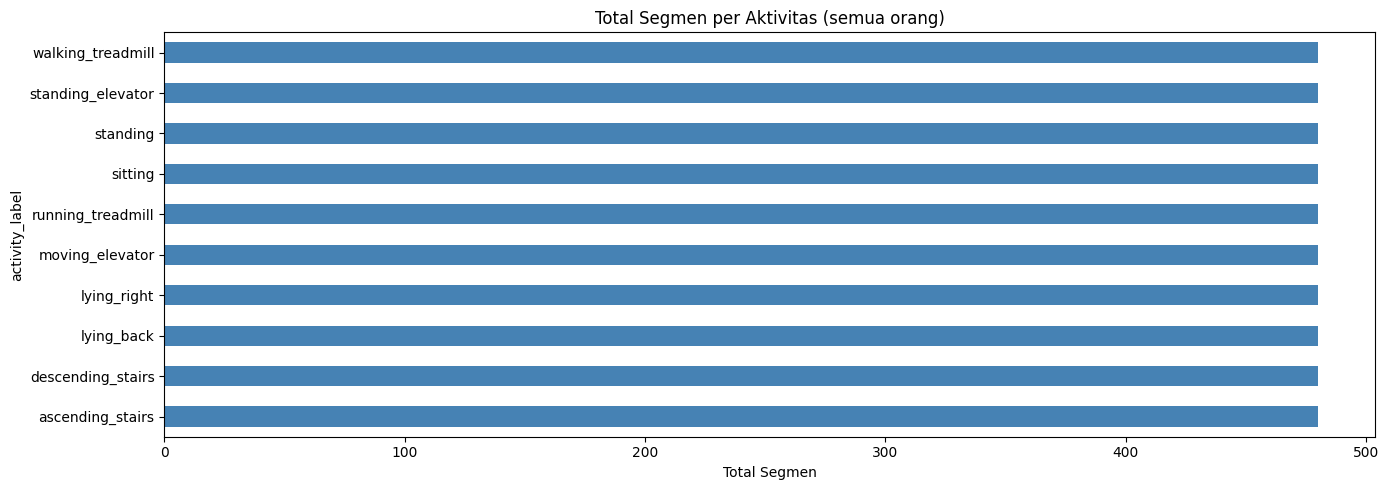

Data sudah seimbang - setiap aktivitas memiliki 60 segmen x 8 orang = 480 segmen


In [ ]:
# Distribusi per aktivitas
activity_counts = raw_df.groupby(['activity_label', 'person_id'])['segment_id'].nunique().reset_index()
activity_counts.columns = ['activity_label', 'person_id', 'n_segments']

plt.figure(figsize=(14, 5))
summary = activity_counts.groupby('activity_label')['n_segments'].sum().sort_values()
summary.plot(kind='barh', color='steelblue')
plt.title('Total Segmen per Aktivitas (semua orang)')
plt.xlabel('Total Segmen')
plt.tight_layout()
plt.show()
print('Data sudah seimbang - setiap aktivitas memiliki 60 segmen x 8 orang = 480 segmen')

In [ ]:
# TAMBAHAN: Magnitude per sensor per bagian tubuh

body_parts = {
    'T':  ('T_xacc',  'T_yacc',  'T_zacc',  'T_xgyro',  'T_ygyro',  'T_zgyro',  'T_xmag',  'T_ymag',  'T_zmag'),
    'RA': ('RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro', 'RA_xmag', 'RA_ymag', 'RA_zmag'),
    'LA': ('LA_xacc', 'LA_yacc', 'LA_zacc', 'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag'),
    'RL': ('RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro', 'RL_xmag', 'RL_ymag', 'RL_zmag'),
    'LL': ('LL_xacc', 'LL_yacc', 'LL_zacc', 'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag'),
}

MAG_COLUMNS = []

for part, cols in body_parts.items():
    xacc, yacc, zacc, xgyro, ygyro, zgyro, xmag, ymag, zmag = cols

    raw_df[f'{part}_acc_mag']  = np.sqrt(raw_df[xacc]**2  + raw_df[yacc]**2  + raw_df[zacc]**2)
    raw_df[f'{part}_gyro_mag'] = np.sqrt(raw_df[xgyro]**2 + raw_df[ygyro]**2 + raw_df[zgyro]**2)
    raw_df[f'{part}_mag_mag']  = np.sqrt(raw_df[xmag]**2  + raw_df[ymag]**2  + raw_df[zmag]**2)

    MAG_COLUMNS += [f'{part}_acc_mag', f'{part}_gyro_mag', f'{part}_mag_mag']

print(f'Kolom magnitude ditambahkan: {len(MAG_COLUMNS)}')
print(MAG_COLUMNS)

Kolom magnitude ditambahkan: 15
['T_acc_mag', 'T_gyro_mag', 'T_mag_mag', 'RA_acc_mag', 'RA_gyro_mag', 'RA_mag_mag', 'LA_acc_mag', 'LA_gyro_mag', 'LA_mag_mag', 'RL_acc_mag', 'RL_gyro_mag', 'RL_mag_mag', 'LL_acc_mag', 'LL_gyro_mag', 'LL_mag_mag']


## 5. Feature Extraction per Segmen

Karena setiap segmen = 125 timestep (5 detik x 25 Hz),
kita ekstrak fitur statistik per segmen untuk setiap sensor.
Ini adalah pendekatan standar untuk HAR dengan ML klasik.

In [ ]:
## 5. Feature Extraction per Segmen

# Karena setiap segmen = 125 timestep (5 detik x 25 Hz), ekstrak fitur statistik per segmen untuk setiap sensor.

def extract_features_per_segment(df, sensor_columns):
    """
    Ekstrak fitur statistik per segmen dari setiap sensor.
    Output: 1 baris per segmen dengan fitur mean, std, min, max, skew, kurtosis
    """
    group_cols = ['activity_id', 'activity_label', 'person_id', 'segment_id']

    feature_dfs = []

    grouped = df.groupby(group_cols)

    for name, group in grouped:
        feat = {}
        feat['activity_id']    = name[0]
        feat['activity_label'] = name[1]
        feat['person_id']      = name[2]
        feat['segment_id']     = name[3]

        sensor_data = group[sensor_columns]

        for col in sensor_columns:
            series = sensor_data[col]
            feat[f'{col}_mean']     = series.mean()
            feat[f'{col}_std']      = series.std()
            feat[f'{col}_min']      = series.min()
            feat[f'{col}_max']      = series.max()
            feat[f'{col}_skew']     = series.skew()
            feat[f'{col}_kurtosis'] = series.kurtosis()

        feature_dfs.append(feat)

    return pd.DataFrame(feature_dfs)


# Gabungkan kolom sensor asli + magnitude
ALL_COLUMNS = SENSOR_COLUMNS + MAG_COLUMNS

print('Mulai feature extraction...')
print(f'  Kolom sensor yang dipakai: {len(ALL_COLUMNS)} ({len(SENSOR_COLUMNS)} sensor asli + {len(MAG_COLUMNS)} magnitude)')
print('  (Proses ini memerlukan beberapa menit)')

feature_df = extract_features_per_segment(raw_df, ALL_COLUMNS)

n_feature_cols = len([c for c in feature_df.columns if c not in ['activity_id', 'activity_label', 'person_id', 'segment_id']])
print(f'\nHasil feature extraction:')
print(f'Total segmen (baris) : {len(feature_df):,}')
print(f'Total fitur          : {n_feature_cols}  ({len(ALL_COLUMNS)} kolom x 6 statistik)')
print(f'\nSample 3 baris pertama:')
print(feature_df.head(3))

Mulai feature extraction...
  Kolom sensor yang dipakai: 60 (45 sensor asli + 15 magnitude)
  (Proses ini memerlukan beberapa menit)

Hasil feature extraction:
Total segmen (baris) : 4,800
Total fitur          : 360  (60 kolom x 6 statistik)

Sample 3 baris pertama:
  activity_id activity_label  person_id  segment_id  T_xacc_mean  T_xacc_std  \
0         a01        sitting          1           1     7.975714    0.119981   
1         a01        sitting          1           2     7.978250    0.086896   
2         a01        sitting          1           3     7.970894    0.055603   

   T_xacc_min  T_xacc_max  T_xacc_skew  T_xacc_kurtosis  ...  LL_gyro_mag_min  \
0      7.6823      8.1605    -0.023603        -1.011485  ...         0.002558   
1      7.8472      8.1763     0.559149        -0.916460  ...         0.002901   
2      7.8470      8.0860     0.101763        -0.905424  ...         0.001604   

   LL_gyro_mag_max  LL_gyro_mag_skew  LL_gyro_mag_kurtosis  LL_mag_mag_mean  \
0       

## 6. Tambahkan Kategori Aktivitas


In [ ]:
# Tambahkan kategori aktivitas (sedentary / light / moderate / intense)
feature_df['activity_category'] = feature_df['activity_label'].map(ACTIVITY_CATEGORIES)

print('Distribusi kategori aktivitas:')
print(feature_df['activity_category'].value_counts())
print()

# Kolom fitur saja (exclude metadata)
meta_cols    = ['activity_id', 'activity_label', 'activity_category', 'person_id', 'segment_id']
feature_cols = [c for c in feature_df.columns if c not in meta_cols]

print(f'Total kolom fitur: {len(feature_cols)}')
print('Normalisasi akan dilakukan di dalam Spark Pipeline menggunakan Spark StandardScaler.')


Distribusi kategori aktivitas:
activity_category
sedentary           2400
light_activity      1920
intense_activity     480
Name: count, dtype: int64

Total kolom fitur: 360
Normalisasi akan dilakukan di dalam Spark Pipeline menggunakan Spark StandardScaler.


## 7. Split Train/Test per Orang

**Penting:** Split dilakukan per orang, bukan per baris.
Ini mencegah data leakage dan membuat model bisa generalisasi ke orang baru.
- Training: orang 1-6 (75%)
- Testing : orang 7-8 (25%)

In [ ]:
# Split berdasarkan person_id
train_df = feature_df[feature_df['person_id'].isin(TRAIN_PERSONS)].copy()
test_df  = feature_df[feature_df['person_id'].isin(TEST_PERSONS)].copy()

print(f'Training set : {len(train_df):,} segmen dari orang {TRAIN_PERSONS}')
print(f'Testing set  : {len(test_df):,} segmen dari orang {TEST_PERSONS}')
print(f'Total fitur  : {len(feature_cols)}')
print(f'\nDistribusi kelas di training set:')
print(train_df['activity_label'].value_counts().sort_index())
print(f'\nDistribusi kelas di testing set:')
print(test_df['activity_label'].value_counts().sort_index())


Training set : 3,600 segmen dari orang [1, 2, 3, 4, 5, 6]
Testing set  : 1,200 segmen dari orang [7, 8]
Total fitur  : 360

Distribusi kelas di training set:
activity_label
ascending_stairs     360
descending_stairs    360
lying_back           360
lying_right          360
moving_elevator      360
running_treadmill    360
sitting              360
standing             360
standing_elevator    360
walking_treadmill    360
Name: count, dtype: int64

Distribusi kelas di testing set:
activity_label
ascending_stairs     120
descending_stairs    120
lying_back           120
lying_right          120
moving_elevator      120
running_treadmill    120
sitting              120
standing             120
standing_elevator    120
walking_treadmill    120
Name: count, dtype: int64


## 8. Simpan Dataset Hasil Preprocessing


In [ ]:
# Mount Google Drive agar semua output tersimpan permanen
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/HAR_SmartHealth/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Direktori penyimpanan: {SAVE_DIR}')

# Simpan raw dataset (sebelum feature extraction)
raw_output_path = SAVE_DIR + 'raw_dataset.csv'
raw_df.to_csv(raw_output_path, index=False)
print(f'Raw dataset     : {raw_output_path} ({os.path.getsize(raw_output_path)/1024/1024:.2f} MB)')

# Simpan feature dataset
feature_output_path = SAVE_DIR + 'feature_dataset.csv'
feature_df.to_csv(feature_output_path, index=False)
print(f'Feature dataset : {feature_output_path} ({os.path.getsize(feature_output_path)/1024/1024:.2f} MB)')

# Simpan train/test split
train_df.to_csv(SAVE_DIR + 'train_set.csv', index=False)
test_df.to_csv(SAVE_DIR + 'test_set.csv', index=False)
print(f'Train set       : {SAVE_DIR}train_set.csv')
print(f'Test set        : {SAVE_DIR}test_set.csv')
print('\nSemua CSV berhasil disimpan ke Google Drive!')


Mounted at /content/drive
Direktori penyimpanan: /content/drive/MyDrive/HAR_SmartHealth/
Raw dataset     : /content/drive/MyDrive/HAR_SmartHealth/raw_dataset.csv (389.94 MB)
Feature dataset : /content/drive/MyDrive/HAR_SmartHealth/feature_dataset.csv (27.19 MB)
Train set       : /content/drive/MyDrive/HAR_SmartHealth/train_set.csv
Test set        : /content/drive/MyDrive/HAR_SmartHealth/test_set.csv

Semua CSV berhasil disimpan ke Google Drive!


## 9. Modeling dengan Apache Spark MLlib (Random Forest)

Pada tahap ini, model Random Forest diimplementasikan menggunakan **Apache Spark MLlib** (`pyspark.ml`). Ini merepresentasikan alur kerja nyata pipeline Big Data, di mana data dalam skala besar diproses secara terdistribusi oleh Spark.

**Alur Spark ML Pipeline:**
1. `StringIndexer` → encode label string ke numeric
2. `VectorAssembler` → gabungkan semua kolom fitur ke satu vektor
3. `StandardScaler` → normalisasi fitur
4. `RandomForestClassifier` → training model

Model dan metadata pendukung disimpan ke **Google Drive**.


In [ ]:
# Install PySpark (jika belum tersedia di Colab)
!pip install pyspark -q

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler as SparkScaler
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline as SparkPipeline

spark = SparkSession.builder \
    .appName('HAR-RandomForest-SparkMLlib') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

print(f'Spark version: {spark.version}')
print('SparkSession berhasil dibuat!')


Spark version: 4.0.2
SparkSession berhasil dibuat!


In [ ]:
# Konversi data MENTAH ke Spark DataFrame
# Pakai train_df / test_df pandas langsung
spark_train = spark.createDataFrame(train_df)
spark_test  = spark.createDataFrame(test_df)

print(f'Spark Train rows : {spark_train.count():,}')
print(f'Spark Test rows  : {spark_test.count():,}')
print(f'Jumlah fitur     : {len(feature_cols)}')
print('Sumber data      : train_df / test_df (unscaled)')
print('Scaling dilakukan oleh SparkScaler di dalam pipeline.')


Spark Train rows : 3,600
Spark Test rows  : 1,200
Jumlah fitur     : 360
Sumber data      : train_df / test_df (unscaled)
Scaling dilakukan oleh SparkScaler di dalam pipeline.


In [ ]:
# Build Spark ML Pipeline
# Hyperparameter diselaraskan dengan RF untuk klasifikasi yang optimal:
#   numTrees   = N_ESTIMATORS (300)
#   maxDepth   = 20 (Spark max = 30; ekuivalen 'unbounded')
#   featureSubset = 'sqrt'

# 1. StringIndexer: encode label string -> numeric index
#    handleInvalid='error' agar terdeteksi jika ada label tak dikenal
indexer = StringIndexer(
    inputCol='activity_label',
    outputCol='label',
    handleInvalid='error'
)

# 2. VectorAssembler: gabungkan semua kolom fitur -> satu vektor
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='raw_features'
)

# 3. StandardScaler: normalisasi (withMean=True agar zero-centered)
spark_scaler = SparkScaler(
    inputCol='raw_features',
    outputCol='features',
    withMean=True,
    withStd=True
)

# 4. Random Forest Classifier
spark_rf = SparkRF(
    featuresCol='features',
    labelCol='label',
    numTrees=N_ESTIMATORS,         # 300
    maxDepth=20,                    # ekuivalen 'unbounded'
    minInstancesPerNode=1,
    featureSubsetStrategy='sqrt',
    seed=42
)

spark_pipeline = SparkPipeline(stages=[indexer, assembler, spark_scaler, spark_rf])

print(f'Training Spark MLlib Random Forest...')
print(f'  numTrees          : {N_ESTIMATORS}')
print(f'  maxDepth          : 20 (ekuivalen unbounded)')
print(f'  featureSubsetStrat: sqrt')
print(f'  Total fitur       : {len(feature_cols)}')
print()

import time as _time
t0_spark = _time.time()
spark_model = spark_pipeline.fit(spark_train)
spark_train_time = _time.time() - t0_spark
print(f'Training selesai dalam {spark_train_time:.1f} detik!')


Training Spark MLlib Random Forest...
  numTrees          : 300
  maxDepth          : 20 (ekuivalen unbounded)
  featureSubsetStrat: sqrt
  Total fitur       : 360

Training selesai dalam 86.4 detik!


In [ ]:
# Prediksi & Evaluasi di Test Set

predictions = spark_model.transform(spark_test)

# Evaluator
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
)
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
evaluator_prec = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='weightedPrecision'
)
evaluator_rec = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='weightedRecall'
)

f1_spark   = evaluator_f1.evaluate(predictions)
acc_spark  = evaluator_acc.evaluate(predictions)
prec_spark = evaluator_prec.evaluate(predictions)
rec_spark  = evaluator_rec.evaluate(predictions)

print('=' * 50)
print('HASIL EVALUASI - Spark MLlib Random Forest')
print('=' * 50)
print(f'F1-Score (weighted)        : {f1_spark:.4f} ({f1_spark*100:.2f}%)')
print(f'Accuracy                   : {acc_spark:.4f} ({acc_spark*100:.2f}%)')
print(f'Precision (weighted)       : {prec_spark:.4f} ({prec_spark*100:.2f}%)')
print(f'Recall (weighted)          : {rec_spark:.4f} ({rec_spark*100:.2f}%)')
print()

# Map prediction index back to label name for Confusion Matrix
indexer_model = spark_model.stages[0]
labels_list = indexer_model.labels

# Convert only necessary columns to Pandas for Confusion Matrix
eval_pd = predictions.select('activity_label', 'prediction').toPandas()
eval_pd['predicted_label'] = eval_pd['prediction'].astype(int).map(lambda idx: labels_list[idx])

confusion_matrix_df = pd.crosstab(
    eval_pd['activity_label'],
    eval_pd['predicted_label'],
    rownames=['Actual'],
    colnames=['Predicted']
)

print('=== CONFUSION MATRIX (Pandas Crosstab) ===')
print(confusion_matrix_df)
print()

# Tampilkan sample prediksi dengan label asli
print('Sample 10 prediksi:')
predictions.select('activity_label', 'label', 'prediction').show(10, truncate=False)


HASIL EVALUASI - Spark MLlib Random Forest
F1-Score (weighted)        : 0.8557 (85.57%)
Accuracy                   : 0.8658 (86.58%)
Precision (weighted)       : 0.8856 (88.56%)
Recall (weighted)          : 0.8658 (86.58%)

=== CONFUSION MATRIX (Pandas Crosstab) ===
Predicted          ascending_stairs  descending_stairs  lying_back  \
Actual                                                               
ascending_stairs                116                  0           0   
descending_stairs                 0                119           0   
lying_back                        0                  0         120   
lying_right                       0                  0           0   
moving_elevator                   0                  0           0   
running_treadmill                 0                  0           0   
sitting                           0                  0           0   
standing                          0                  0           0   
standing_elevator                

In [ ]:
import pickle
import os

# SIMPAN SEMUA ARTEFAK KE GOOGLE DRIVE

# --- 1. Spark Model (native Spark PipelineModel format) ---
spark_model_path = SAVE_DIR + 'spark_rf_pipeline_model'
spark_model.write().overwrite().save(spark_model_path)
print(f'[1] Spark PipelineModel disimpan ke : {spark_model_path}')

# --- 2. Label mapping (dari StringIndexer Spark ke PKL) ---
indexer_model  = spark_model.stages[0]  # fitted StringIndexerModel
label_mapping = {
    'label_to_index': {label: i for i, label in enumerate(indexer_model.labels)},
    'index_to_label': {i: label for i, label in enumerate(indexer_model.labels)},
    'labels': list(indexer_model.labels)
}

label_mapping_path = SAVE_DIR + 'label_mapping.pkl'
with open(label_mapping_path, 'wb') as f:
    pickle.dump(label_mapping, f)
print(f'[2] Label mapping (PKL) disimpan    : {label_mapping_path}')

# --- 3. Feature columns metadata (ke PKL) ---
feature_meta_path = SAVE_DIR + 'feature_cols.pkl'
with open(feature_meta_path, 'wb') as f:
    pickle.dump(feature_cols, f)
print(f'[3] Feature cols (PKL) disimpan     : {feature_meta_path}')

print()
print('=' * 50)
print('Semua Spark artefak berhasil disimpan ke Google Drive!')
print('=' * 50)
print(f'  Direktori : {SAVE_DIR}')
for f in os.listdir(SAVE_DIR):
    full_p = os.path.join(SAVE_DIR, f)
    if os.path.isfile(full_p):
        size_kb = os.path.getsize(full_p) / 1024
        print(f'  {f:<40} {size_kb:.1f} KB')
    else:
        print(f'  {f:<40} [folder]')


[1] Spark PipelineModel disimpan ke : /content/drive/MyDrive/HAR_SmartHealth/spark_rf_pipeline_model
[2] Label mapping (PKL) disimpan    : /content/drive/MyDrive/HAR_SmartHealth/label_mapping.pkl
[3] Feature cols (PKL) disimpan     : /content/drive/MyDrive/HAR_SmartHealth/feature_cols.pkl

Semua Spark artefak berhasil disimpan ke Google Drive!
  Direktori : /content/drive/MyDrive/HAR_SmartHealth/
  scaler.pkl                               9.0 KB
  label_mapping.pkl                        0.6 KB
  feature_cols.pkl                         5.7 KB
  sklearn_rf_model.pkl                     1661.4 KB
  full_sklearn_pipeline.pkl                1670.3 KB
  raw_dataset.csv                          399294.2 KB
  feature_dataset.csv                      27841.3 KB
  train_set.csv                            20867.8 KB
  test_set.csv                             6978.6 KB
  spark_rf_pipeline_model                  [folder]


In [ ]:
# DEMO INFERENSI: Load Model dari Drive & Prediksi Sampel Baru
# Simulasi: 5 sampel acak dari test set sebagai 'data baru'

from pyspark.ml import PipelineModel
import pickle

# Load Spark model dari Drive
loaded_spark_model  = PipelineModel.load(spark_model_path)

# Load metadata PKL
with open(label_mapping_path, 'rb') as f:
    loaded_label_map = pickle.load(f)
with open(feature_meta_path, 'rb') as f:
    loaded_feature_cols = pickle.load(f)

print('Semua Spark artefak berhasil di-load dari Google Drive!')
print(f'  Jumlah fitur : {len(loaded_feature_cols)}')
print(f'  Jumlah kelas : {len(loaded_label_map["labels"])}')
print()

# Buat data dummy baru: ambil dari raw test_df, simulasi sensor baru
dummy_samples = test_df[feature_cols].sample(5, random_state=99).copy()
dummy_labels  = test_df.loc[dummy_samples.index, 'activity_label'].values
dummy_samples['activity_label'] = dummy_labels
dummy_samples = dummy_samples.reset_index(drop=True)

dummy_spark = spark.createDataFrame(dummy_samples)

# Prediksi menggunakan model yang di-load
result = loaded_spark_model.transform(dummy_spark)

index_to_label = loaded_label_map['index_to_label']
result_pd = result.select('activity_label', 'prediction').toPandas()
result_pd['predicted_label'] = result_pd['prediction'].astype(int).map(lambda x: index_to_label[x])
result_pd['status'] = result_pd.apply(
    lambda r: 'BENAR v' if r['activity_label'] == r['predicted_label'] else 'SALAH x', axis=1
)

print('=' * 65)
print('DEMO HASIL INFERENSI (5 sampel data baru dari sensor)')
print('=' * 65)
print(result_pd[['activity_label', 'predicted_label', 'status']].to_string(index=False))
print()
correct = (result_pd['status'] == 'BENAR v').sum()
print(f'Hasil: {correct}/5 prediksi benar')
print('Pipeline Spark MLlib siap digunakan untuk produksi!')


Semua Spark artefak berhasil di-load dari Google Drive!
  Jumlah fitur : 360
  Jumlah kelas : 10

DEMO HASIL INFERENSI (5 sampel data baru dari sensor)
   activity_label   predicted_label  status
walking_treadmill walking_treadmill BENAR v
      lying_right       lying_right BENAR v
standing_elevator   moving_elevator SALAH x
       lying_back        lying_back BENAR v
descending_stairs descending_stairs BENAR v

Hasil: 4/5 prediksi benar
Pipeline Spark MLlib siap digunakan untuk produksi!


In [ ]:
# RINGKASAN AKHIR: Preprocessing & Modeling

print('=' * 65)
print('RINGKASAN AKHIR — Preprocessing & Modeling dengan Spark MLlib')
print('=' * 65)
print(f'Dataset         : UCI Daily and Sports Activities')
print(f'Aktivitas       : {len(SELECTED_ACTIVITIES)} dari 19')
print(f'Orang Train     : {TRAIN_PERSONS}')
print(f'Orang Test      : {TEST_PERSONS}')
print(f'n_estimators    : {N_ESTIMATORS}')
print(f'max_depth       : 20 (ekuivalen unbounded)')
print(f'F1 (weighted)   : {f1_spark*100:.2f}%')
print(f'Accuracy        : {acc_spark*100:.2f}%')
print(f'Training time   : {spark_train_time:.1f}s')
print(f'─'*65)
print(f'Model artifacts :')
print(f'  spark_rf_pipeline_model/  -> Spark PipelineModel (native)')
print(f'  label_mapping.pkl         -> index <-> label mapping')
print(f'  feature_cols.pkl          -> daftar {len(feature_cols)} fitur')
print(f'─'*65)
print(f'Semua artefak tersimpan di: {SAVE_DIR}')
print('=' * 65)


RINGKASAN AKHIR — Preprocessing & Modeling dengan Spark MLlib
Dataset         : UCI Daily and Sports Activities
Aktivitas       : 10 dari 19
Orang Train     : [1, 2, 3, 4, 5, 6]
Orang Test      : [7, 8]
n_estimators    : 300
max_depth       : 20 (ekuivalen unbounded)
F1 (weighted)   : 85.57%
Accuracy        : 86.58%
Training time   : 86.4s
─────────────────────────────────────────────────────────────────
Model artifacts :
  spark_rf_pipeline_model/  -> Spark PipelineModel (native)
  label_mapping.pkl         -> index <-> label mapping
  feature_cols.pkl          -> daftar 360 fitur
─────────────────────────────────────────────────────────────────
Semua artefak tersimpan di: /content/drive/MyDrive/HAR_SmartHealth/
